<a href="https://colab.research.google.com/github/Hakan-AKILLI/Anomaly-Detection-with-SMOTE/blob/main/SMOTE_Anomaly_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Colab'a hoş geldiniz.

Ağ trafik logları yükleniyor...
Veri seti başarıyla yüklendi!

Ağ Trafiği Sınıf Dağılımı:
Attack_Category
Normal                67343
DoS                   45927
Probe (Tarama)        11656
R2L (Sızma)             995
U2R (Root Yetkisi)       52
Name: count, dtype: int64

En tehlikeli sızma saldırılarının (U2R ve R2L) tüm trafiğe oranı: Sadece % 0.831!


/tmp/ipykernel_34863/579792001.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Attack_Category', data=df, order=kategori_sayilari.index, palette='magma')


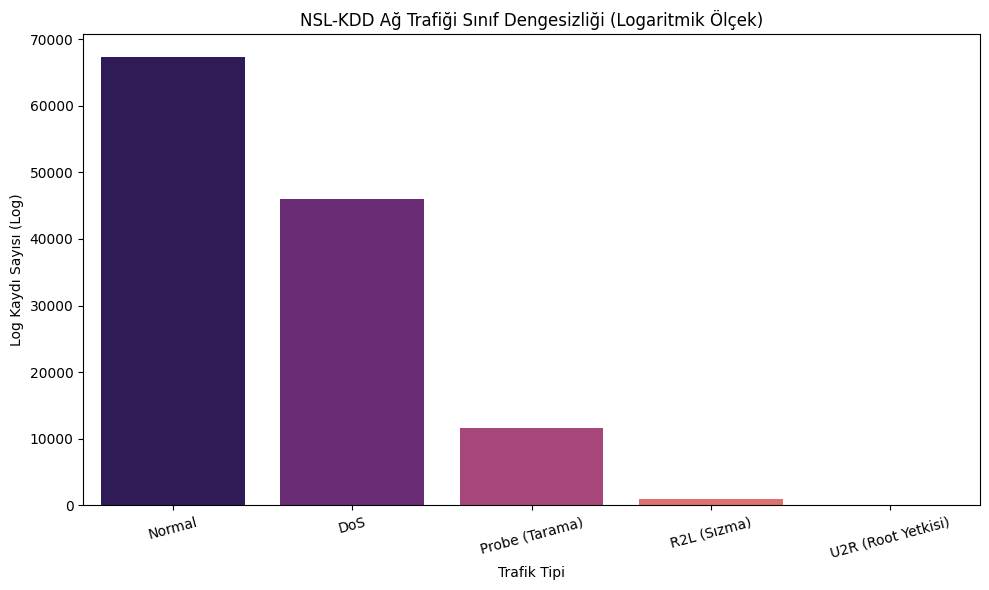

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NSL-KDD veri setinin standart ağ paketi özellikleri (41 özellik + 1 etiket)
kolonlar = ["duration", "protocol_type", "service", "flag", "src_bytes",
            "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
            "num_failed_logins", "logged_in", "num_compromised", "root_shell",
            "su_attempted", "num_root", "num_file_creations", "num_shells",
            "num_access_files", "num_outbound_cmds", "is_host_login",
            "is_guest_login", "count", "srv_count", "serror_rate",
            "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
            "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
            "dst_host_srv_count", "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
            "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
            "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate",
            "dst_host_srv_rerror_rate", "label"]

# Veriyi yüklüyoruz (Dosya adını Colab'a yüklediğin isimle eşleştir, genelde KDDTrain+.txt'dir)
# NSL-KDD'nin son sütununda fazladan bir 'zorluk derecesi' (difficulty level) olabilir, onu dışarıda bırakıyoruz.
print("Ağ trafik logları yükleniyor...")
df = pd.read_csv('KDDTrain+.txt', names=kolonlar, usecols=range(42))
print("Veri seti başarıyla yüklendi!\n")

# Alt saldırı türlerini 4 ana siber tehdit kategorisine ayırıyoruz
saldiri_kategorileri = {
    'normal': 'Normal',
    'neptune': 'DoS', 'smurf': 'DoS', 'pod': 'DoS', 'teardrop': 'DoS', 'land': 'DoS', 'back': 'DoS', 'apache2': 'DoS', 'udpstorm': 'DoS', 'processtable': 'DoS', 'mailbomb': 'DoS',
    'satan': 'Probe (Tarama)', 'ipsweep': 'Probe (Tarama)', 'nmap': 'Probe (Tarama)', 'portsweep': 'Probe (Tarama)', 'mscan': 'Probe (Tarama)', 'saint': 'Probe (Tarama)',
    'guess_passwd': 'R2L (Sızma)', 'ftp_write': 'R2L (Sızma)', 'imap': 'R2L (Sızma)', 'phf': 'R2L (Sızma)', 'multihop': 'R2L (Sızma)', 'warezmaster': 'R2L (Sızma)', 'warezclient': 'R2L (Sızma)', 'spy': 'R2L (Sızma)', 'xlock': 'R2L (Sızma)', 'xsnoop': 'R2L (Sızma)', 'snmpguess': 'R2L (Sızma)', 'snmpgetattack': 'R2L (Sızma)', 'httptunnel': 'R2L (Sızma)', 'sendmail': 'R2L (Sızma)', 'named': 'R2L (Sızma)',
    'buffer_overflow': 'U2R (Root Yetkisi)', 'loadmodule': 'U2R (Root Yetkisi)', 'rootkit': 'U2R (Root Yetkisi)', 'perl': 'U2R (Root Yetkisi)', 'sqlattack': 'U2R (Root Yetkisi)', 'xterm': 'U2R (Root Yetkisi)', 'ps': 'U2R (Root Yetkisi)'
}

# Etiketleri ana kategorilere eşleyelim
df['Attack_Category'] = df['label'].map(lambda x: saldiri_kategorileri.get(x, 'Bilinmeyen (0-Day)'))

# Dağılımı hesaplayıp ekrana yazdıralım
kategori_sayilari = df['Attack_Category'].value_counts()
print("Ağ Trafiği Sınıf Dağılımı:")
print(kategori_sayilari)

# U2R ve R2L gibi nadir ama kritik saldırıların oranını hesaplayalım
toplam_kayit = len(df)
nadir_saldirilar = kategori_sayilari.get('U2R (Root Yetkisi)', 0) + kategori_sayilari.get('R2L (Sızma)', 0)
print(f"\nEn tehlikeli sızma saldırılarının (U2R ve R2L) tüm trafiğe oranı: Sadece % {(nadir_saldirilar / toplam_kayit) * 100:.3f}!")

# Proje Raporuna koyacağımız o meşhur Sınıf Dengesizliği Grafiği
plt.figure(figsize=(10, 6))
# Fark çok devasa olduğu için Y eksenini Logaritmik yapıyoruz ki nadir saldırılar grafikte görülebilsin
sns.countplot(x='Attack_Category', data=df, order=kategori_sayilari.index, palette='magma')
plt.title('NSL-KDD Ağ Trafiği Sınıf Dengesizliği (Logaritmik Ölçek)')
plt.xlabel('Trafik Tipi')
plt.ylabel('Log Kaydı Sayısı (Log)')
plt.yscale('log')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [ ]:
# Dosyayı hiçbir sütun ismi vermeden ve hiçbir ekleme yapmadan okuyoruz
#ham_veri = pd.read_csv('KDDTrain+.txt', header=None)

# İlk 5 satırı ekrana yazdırıyoruz
df.sample(50)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,Attack_Category
2512,0,tcp,http,SF,323,2052,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,Normal
74704,0,tcp,http,SF,310,5103,0,0,0,0,...,1.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,normal,Normal
92609,0,tcp,http,SF,308,405,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,Normal
30763,0,tcp,http,SF,296,1601,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,Normal
18560,0,tcp,private,S0,0,0,0,0,0,0,...,0.07,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,DoS
86271,0,tcp,http,SF,195,313,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,Normal
68086,0,tcp,http,SF,244,263,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,Normal
32242,0,tcp,whois,REJ,0,0,0,0,0,0,...,0.03,0.08,0.00,0.00,0.00,0.00,1.00,1.00,neptune,DoS
16429,0,tcp,private,S0,0,0,0,0,0,0,...,0.03,0.07,0.00,0.00,1.00,1.00,0.00,0.00,neptune,DoS
16485,0,udp,domain_u,SF,46,71,0,0,0,0,...,0.95,0.01,0.00,0.00,0.00,0.00,0.00,0.00,normal,Normal
